In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:

df=pd.read_csv(r"C:\Users\EVO TECH\Downloads\New folder\Inventory Management E-Grocery - InventoryData.csv")
print(df.head())

    SKU_ID              SKU_Name       Category ABC_Class Supplier_ID  \
0  SKU0001     Pantry Product 13         Pantry         A        S005   
1  SKU0002     Fresh Product 112  Fresh Produce         C        S004   
2  SKU0003      Meat Product 446           Meat         B        S001   
3  SKU0004    Seafood Product 48        Seafood         A        S007   
4  SKU0005  Personal Product 194  Personal Care         A        S002   

           Supplier_Name Warehouse_ID    Warehouse_Location   Batch_ID  \
0           PT Agro Raya        WHBDG   Bandung - Rancaekek  BATCH2679   
1  PT Nusantara Supplier        WHDPS    Denpasar - Tabanan  BATCH4257   
2        PT Segar Makmur        WHBDG   Bandung - Rancaekek  BATCH6574   
3           PT Bakerindo        WHJKT  Jakarta - Cengkareng  BATCH5333   
4          PT Indo Fresh        WHDPS    Denpasar - Tabanan  BATCH6925   

  Received_Date  ... SKU_Churn_Rate Order_Frequency_per_month  \
0    2025-07-14  ...           2,39                

In [27]:
print(list(df.columns))

['SKU_ID', 'SKU_Name', 'Category', 'ABC_Class', 'Supplier_ID', 'Supplier_Name', 'Warehouse_ID', 'Warehouse_Location', 'Batch_ID', 'Received_Date', 'Last_Purchase_Date', 'Expiry_Date', 'Stock_Age_Days', 'Quantity_On_Hand', 'Quantity_Reserved', 'Quantity_Committed', 'Damaged_Qty', 'Returns_Qty', 'Avg_Daily_Sales', 'Forecast_Next_30d', 'Days_of_Inventory', 'Reorder_Point', 'Safety_Stock', 'Lead_Time_Days', 'Unit_Cost_USD', 'Last_Purchase_Price_USD', 'Total_Inventory_Value_USD', 'SKU_Churn_Rate', 'Order_Frequency_per_month', 'Supplier_OnTime_Pct', 'FIFO_FEFO', 'Inventory_Status', 'Count_Variance', 'Audit_Date', 'Audit_Variance_Pct', 'Demand_Forecast_Accuracy_Pct', 'Notes']


In [28]:
selected_columns = [
    'SKU_ID', 'SKU_Name', 'Category', 'ABC_Class', 
    'Received_Date', 'Expiry_Date', 
    'Quantity_On_Hand', 'Damaged_Qty', 
    'Unit_Cost_USD', 'Total_Inventory_Value_USD', 'FIFO_FEFO'
]

file_path = r"C:\Users\EVO TECH\Downloads\New folder\Inventory Management E-Grocery - InventoryData.csv"
df = pd.read_csv(file_path, usecols=selected_columns)
df['Received_Date'] = pd.to_datetime(df['Received_Date'], errors='coerce')
df['Expiry_Date'] = pd.to_datetime(df['Expiry_Date'], errors='coerce')
print(df.head())

    SKU_ID              SKU_Name       Category ABC_Class Received_Date  \
0  SKU0001     Pantry Product 13         Pantry         A    2025-07-14   
1  SKU0002     Fresh Product 112  Fresh Produce         C    2025-04-08   
2  SKU0003      Meat Product 446           Meat         B    2025-03-15   
3  SKU0004    Seafood Product 48        Seafood         A    2025-06-10   
4  SKU0005  Personal Product 194  Personal Care         A    2025-06-26   

  Expiry_Date  Quantity_On_Hand  Damaged_Qty Unit_Cost_USD  \
0  2027-04-25               359            0         $5,81   
1  2025-04-11               314            0         $1,45   
2  2025-04-02               485            3         $1,86   
3  2025-06-18               281            0        $14,50   
4  2030-01-03               235            0         $9,46   

  Total_Inventory_Value_USD FIFO_FEFO  
0                 $2.084,25      FIFO  
1                   $456,71      FEFO  
2                   $902,63      FIFO  
3               

In [29]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   SKU_ID                     1000 non-null   str           
 1   SKU_Name                   1000 non-null   str           
 2   Category                   1000 non-null   str           
 3   ABC_Class                  1000 non-null   str           
 4   Received_Date              1000 non-null   datetime64[us]
 5   Expiry_Date                1000 non-null   datetime64[us]
 6   Quantity_On_Hand           1000 non-null   int64         
 7   Damaged_Qty                1000 non-null   int64         
 8   Unit_Cost_USD              1000 non-null   str           
 9   Total_Inventory_Value_USD  1000 non-null   str           
 10  FIFO_FEFO                  1000 non-null   str           
dtypes: datetime64[us](2), int64(2), str(7)
memory usage: 86.1 KB
SKU_ID              

In [30]:

df['Unit_Cost_USD'] = df['Unit_Cost_USD'].str.replace('$', '').str.replace(',', '').astype(float)
df['Total_Inventory_Value_USD'] = df['Total_Inventory_Value_USD'].str.replace('$', '').str.replace(',', '').astype(float)
df['Shelf_Life_Days'] = (df['Expiry_Date'] - df['Received_Date']).dt.days
print(df[['Unit_Cost_USD', 'Total_Inventory_Value_USD', 'Shelf_Life_Days']].dtypes)

Unit_Cost_USD                float64
Total_Inventory_Value_USD    float64
Shelf_Life_Days                int64
dtype: object


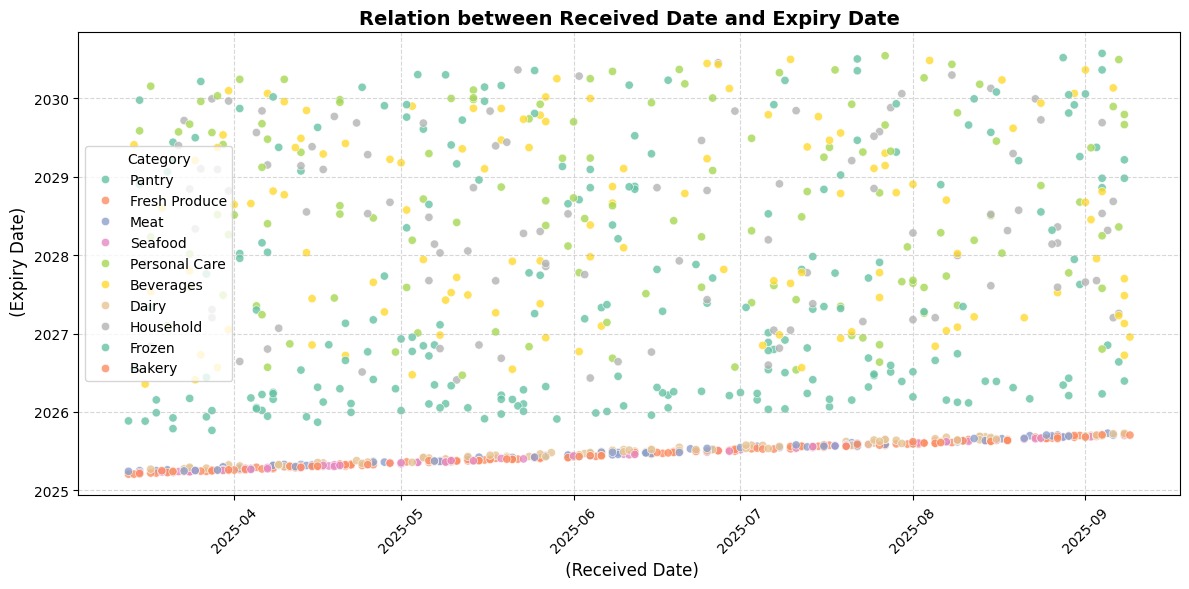

In [31]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, 
    x='Received_Date', 
    y='Expiry_Date', 
    hue='Category', 
    palette='Set2', 
    alpha=0.8
)

plt.title('Relation between Received Date and Expiry Date', fontsize=14, fontweight='bold')
plt.xlabel(' (Received Date)', fontsize=12)
plt.ylabel(' (Expiry Date)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [32]:
print(df.groupby('Category')['FIFO_FEFO'].value_counts())

Category       FIFO_FEFO
Bakery         FEFO         35
               FIFO         34
Beverages      FIFO         63
               FEFO         57
Dairy          FIFO         52
               FEFO         44
Fresh Produce  FEFO         61
               FIFO         49
Frozen         FIFO         46
               FEFO         40
Household      FEFO         52
               FIFO         51
Meat           FIFO         48
               FEFO         39
Pantry         FIFO         70
               FEFO         67
Personal Care  FIFO         68
               FEFO         58
Seafood        FIFO         35
               FEFO         31
Name: count, dtype: int64


In [33]:
fefo_products=df[df['FIFO_FEFO']=='FEFO']
print(fefo_products.head())

     SKU_ID              SKU_Name       Category ABC_Class Received_Date  \
1   SKU0002     Fresh Product 112  Fresh Produce         C    2025-04-08   
5   SKU0006  Beverages Product 41      Beverages         A    2025-06-04   
8   SKU0009     Fresh Product 468  Fresh Produce         B    2025-07-17   
11  SKU0012  Personal Product 271  Personal Care         C    2025-09-07   
16  SKU0017    Pantry Product 494         Pantry         A    2025-03-17   

   Expiry_Date  Quantity_On_Hand  Damaged_Qty  Unit_Cost_USD  \
1   2025-04-11               314            0          145.0   
5   2027-12-25               446            1          516.0   
8   2025-07-30                 1            0          133.0   
11  2030-07-01                66            1          685.0   
16  2027-05-02               197            0         1152.0   

    Total_Inventory_Value_USD FIFO_FEFO  Shelf_Life_Days  
1                 45671.00000      FEFO                3  
5                     2.30314      FEFO 

C:\Users\EVO TECH\AppData\Local\Temp\ipykernel_10872\1672259261.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\EVO TECH\AppData\Local\Temp\ipykernel_10872\1672259261.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


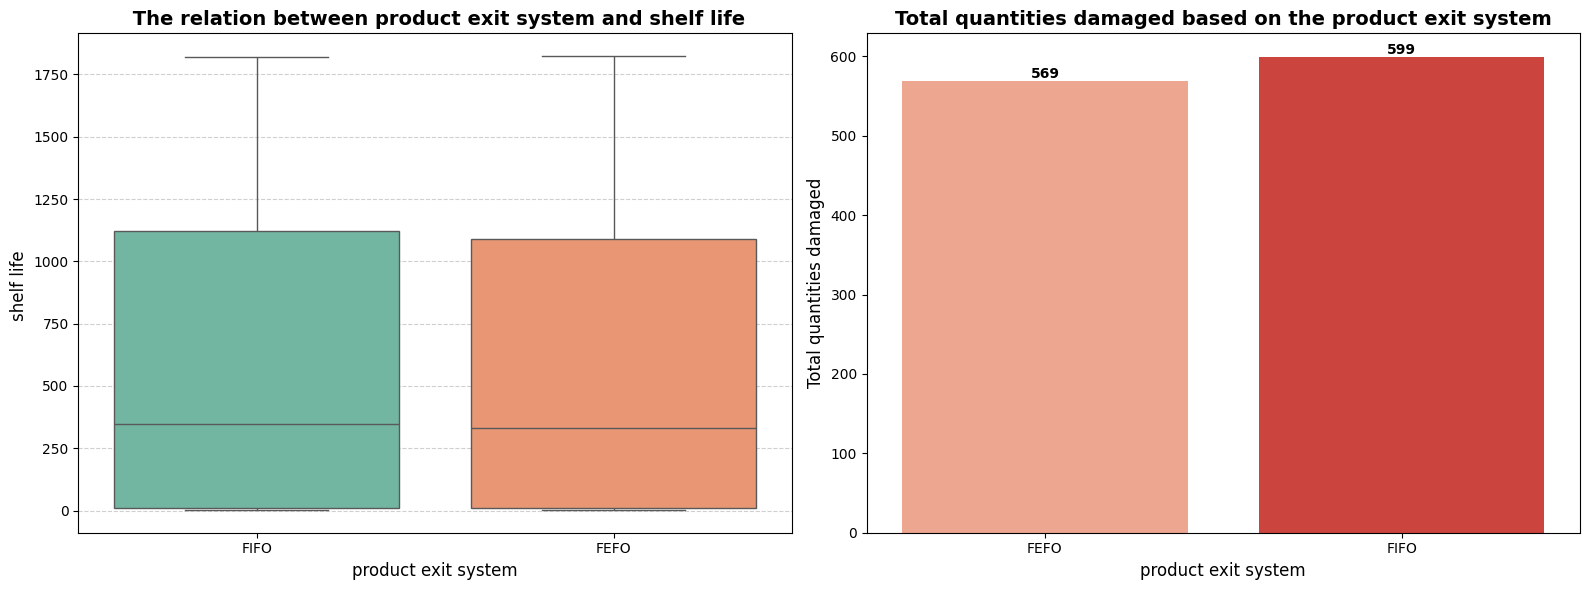

In [34]:

df['Shelf_Life_Days'] = (df['Expiry_Date'] - df['Received_Date']).dt.days
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(
    ax=axes[0],
    data=df, 
    x='FIFO_FEFO', 
    y='Shelf_Life_Days', 
    palette='Set2'
)
axes[0].set_title(' The relation between product exit system and shelf life', fontsize=14, fontweight='bold')
axes[0].set_xlabel('product exit system', fontsize=12)
axes[0].set_ylabel('shelf life ', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

damaged_summary = df.groupby('FIFO_FEFO')['Damaged_Qty'].sum().reset_index()

sns.barplot(
    ax=axes[1],
    data=damaged_summary, 
    x='FIFO_FEFO', 
    y='Damaged_Qty', 
    palette='Reds'
)
axes[1].set_title('Total quantities damaged based on the product exit system', fontsize=14, fontweight='bold')
axes[1].set_xlabel('product exit system', fontsize=12)
axes[1].set_ylabel('Total quantities damaged', fontsize=12)

for index, row in damaged_summary.iterrows():
    axes[1].text(index, row.Damaged_Qty, f'{int(row.Damaged_Qty)}', color='black', ha="center", va="bottom", fontweight='bold')
    
plt.tight_layout()
plt.show()

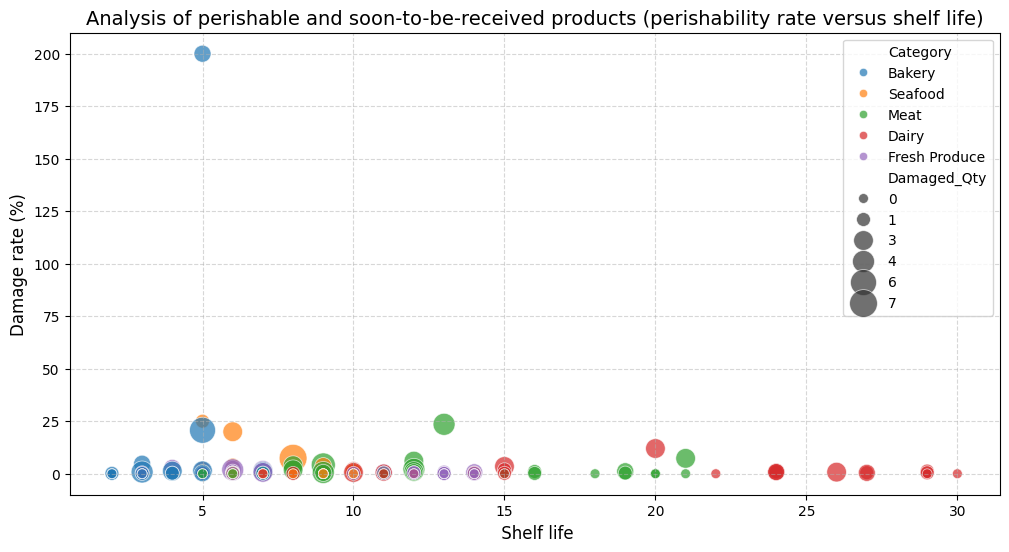

 Products in this range have the highest defect rate
                SKU_Name Category  Shelf_Life_Days  Damage_Ratio
120   Bakery Product 407   Bakery                5    200.000000
109  Seafood Product 253  Seafood                5     25.000000
31      Meat Product 456     Meat               13     23.529412
781   Bakery Product 420   Bakery                5     20.689655
315  Seafood Product 232  Seafood                6     20.000000
775     Dairy Product 81    Dairy               20     12.000000
921  Seafood Product 115  Seafood                8      7.368421
18      Meat Product 464     Meat               21      7.317073
985      Meat Product 61     Meat               12      6.000000
43    Bakery Product 207   Bakery                3      4.761905


In [35]:

recent_date = df['Received_Date'].max() - pd.Timedelta(days=60)
fast_moving_range = df[(df['Shelf_Life_Days'] <= 30) & (df['Received_Date'] >= recent_date)]

fast_moving_range['Damage_Ratio'] = (fast_moving_range['Damaged_Qty'] / fast_moving_range['Quantity_On_Hand']) * 100

report = fast_moving_range.sort_values(by='Damage_Ratio', ascending=False)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=report,
    x='Shelf_Life_Days',
    y='Damage_Ratio',
    hue='Category',
    size='Damaged_Qty', 
    sizes=(50, 400),
    alpha=0.7
)

plt.title('Analysis of perishable and soon-to-be-received products (perishability rate versus shelf life)', fontsize=14)
plt.xlabel(' Shelf life', fontsize=12)
plt.ylabel('Damage rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


print(" Products in this range have the highest defect rate")
print(report[['SKU_Name', 'Category', 'Shelf_Life_Days', 'Damage_Ratio']].head(10))

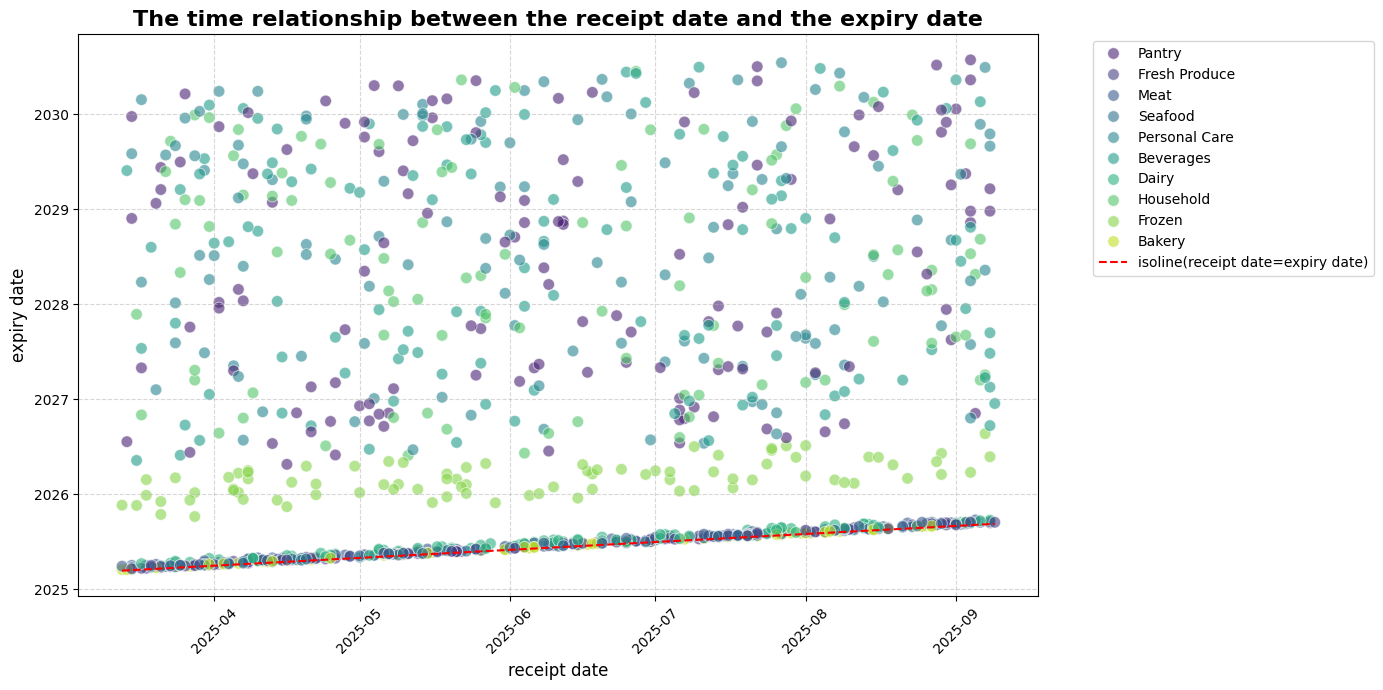

In [36]:

plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=df, 
    x='Received_Date', 
    y='Expiry_Date', 
    hue='Category', 
    palette='viridis', 
    alpha=0.6, 
    s=70
)

plt.plot([df['Received_Date'].min(), df['Received_Date'].max()], 
         [df['Received_Date'].min(), df['Received_Date'].max()], 
         color='red', linestyle='--', label='isoline(receipt date=expiry date)')


plt.title('The time relationship between the receipt date and the expiry date', fontsize=16, fontweight='bold')
plt.xlabel('receipt date', fontsize=12)
plt.ylabel('expiry date', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()